<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW-3/HW3_PT2_322512690_212393532_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Assignment 3 - Part 2
### Latent Space Visualization

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532

# Imports

In [32]:
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F
import random
from sklearn.manifold import TSNE

# Preprocessing

In [33]:
# create a transofrm to apply to each datapoint
transform = transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Encoder Class

In [52]:
class Encoder(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1=nn.Linear(input_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        # get the mean of the latent space
        self.mu=nn.Linear(hidden_dim,latent_dim)
        # get the log var of the latent space
        self.log_var=nn.Linear(hidden_dim,latent_dim)

    def forward(self, x):

      #x=x.view(x.size(0),-1)  #flattern the input
      x=F.relu(self.fc1(x))
      x=F.relu(self.fc2(x))
      mu=self.mu(x)
      log_var=self.log_var(x)

      return mu,log_var


# Decoder Class

In [53]:
class Decoder(nn.Module):

    def __init__(self, output_dim, hidden_dim, latent_dim):
        super(Decoder, self).__init__()
        self.fc1=nn.Linear(latent_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        self.fc3=nn.Linear(hidden_dim,output_dim)



    def forward(self, x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=torch.sigmoid(self.fc3(x))
        #x=x.view(x.size(0),1,28,28)  # reshape to image format
        return x

# Variational Auto Encoder Class

In [54]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200, device=device):
        super(VAE, self).__init__()

        self.device= device
        self.encoder=Encoder(input_dim,hidden_dim,latent_dim)
        self.decoder=Decoder(input_dim,hidden_dim,latent_dim)


    def reparameterize(self,mu,log_var):

        std=torch.exp(0.5*log_var)
        epslion=torch.randn_like(std)
        z=mu+epslion*std
        return z




    def forward(self, x):
        # write your code here

        x=x.view(x.size(0),-1)
        mu,logvar=self.encoder(x)
        z=self.reparameterize(mu,logvar)
        recon_x=self.decoder(z)
        return recon_x,mu,logvar

In [55]:
model = VAE().to(device)
lr=0.001
optimizer = Adam(model.parameters(), lr)

# Loss Function Class


i add the 1e-10 to avoid log(0)

In [59]:
def loss_function(x, x_hat, mean, log_var):
    # write your code heres

    #x_hat=x_hat.view(x.size(0),-1)

    bce_loss=-torch.sum(x*torch.log(x_hat+ 1e-10)+(1-x)*torch.log(1-x_hat+ 1e-10))


    kld=-0.5*torch.sum(1+log_var-mean.pow(2)-log_var.exp())

    return bce_loss+kld



    #return torch.mean(bce_loss + kld)

# Training Loop

In [62]:
def train(model, optimizer, epochs, device, x_dim=784): # Modify, add the evaluation step after each 10 epochs
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, x_dim).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))

        # After 10 epochs , generate and plot a digit
        if (epoch+1) % 10 ==0:

          with torch.no_grad():

            z=torch.randn(1,model.decoder.fc1.in_features,device=device)

            generated_digit=model.decoder(z).squeeze().cpu().detach().numpy()

            generated_digit=generated_digit.reshape(28,28)

            # plot the generated digit
            plt.imshow(generated_digit,cmap='gray')
            plt.axis('off')
            plt.title(f"Generated Image at Epoch {epoch+1}")
            plt.show()


    return overall_loss

	Epoch 1 	Average Loss:  106.07624007134287
	Epoch 2 	Average Loss:  105.54736124334829
	Epoch 3 	Average Loss:  104.91725065864983
	Epoch 4 	Average Loss:  104.290226516851
	Epoch 5 	Average Loss:  103.83649301570325
	Epoch 6 	Average Loss:  103.48794377347663
	Epoch 7 	Average Loss:  103.02682369378653
	Epoch 8 	Average Loss:  102.67211896128966
	Epoch 9 	Average Loss:  102.33439681369991
	Epoch 10 	Average Loss:  102.10859482601211


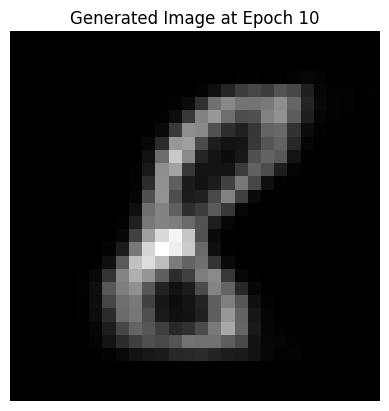

	Epoch 11 	Average Loss:  101.80031274454821
	Epoch 12 	Average Loss:  101.62050261177484
	Epoch 13 	Average Loss:  101.4493213950334
	Epoch 14 	Average Loss:  101.25733471801962
	Epoch 15 	Average Loss:  101.09461542349229
	Epoch 16 	Average Loss:  100.97865819660372
	Epoch 17 	Average Loss:  100.81084876160789
	Epoch 18 	Average Loss:  100.68588420479445
	Epoch 19 	Average Loss:  100.54441629604028
	Epoch 20 	Average Loss:  100.46366695142946


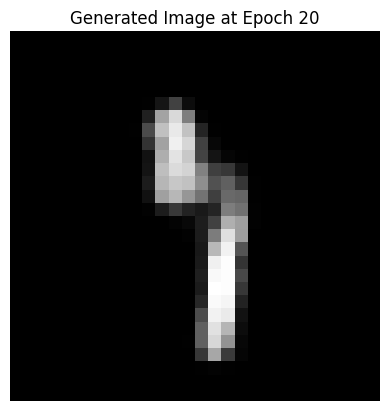

	Epoch 21 	Average Loss:  100.3451542120983
	Epoch 22 	Average Loss:  100.22692165979758
	Epoch 23 	Average Loss:  100.17015634781929
	Epoch 24 	Average Loss:  100.06177287666945
	Epoch 25 	Average Loss:  99.94458240948455
	Epoch 26 	Average Loss:  99.90431433574186
	Epoch 27 	Average Loss:  99.80093187539127
	Epoch 28 	Average Loss:  99.73705704168405
	Epoch 29 	Average Loss:  99.62270489878965
	Epoch 30 	Average Loss:  99.58351772811457


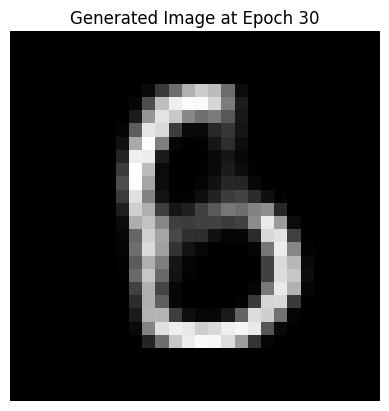

	Epoch 31 	Average Loss:  99.52263741978818
	Epoch 32 	Average Loss:  99.49434901267738
	Epoch 33 	Average Loss:  99.39196099945221
	Epoch 34 	Average Loss:  99.30129939873748
	Epoch 35 	Average Loss:  99.30965693147434
	Epoch 36 	Average Loss:  99.24766820025563
	Epoch 37 	Average Loss:  99.14091814808535
	Epoch 38 	Average Loss:  99.09018740544136
	Epoch 39 	Average Loss:  99.02868984114149
	Epoch 40 	Average Loss:  99.03216686013147


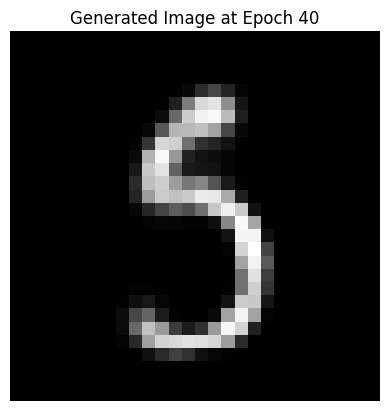

	Epoch 41 	Average Loss:  98.95568136020972
	Epoch 42 	Average Loss:  98.90631222936665
	Epoch 43 	Average Loss:  98.85211170635955
	Epoch 44 	Average Loss:  98.84752326468593
	Epoch 45 	Average Loss:  98.7834647752765
	Epoch 46 	Average Loss:  98.73977811326169
	Epoch 47 	Average Loss:  98.70548071655885
	Epoch 48 	Average Loss:  98.65521334385434
	Epoch 49 	Average Loss:  98.6187715691517
	Epoch 50 	Average Loss:  98.58150245526399


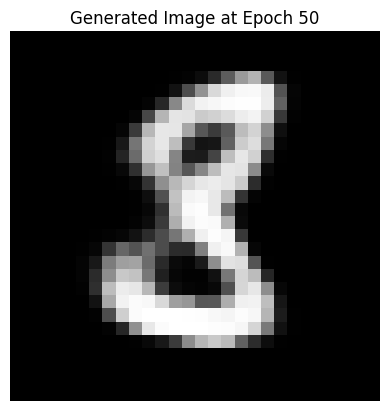

5905031.9970703125

In [63]:
train(model, optimizer, epochs=50, device=device)

# Generate and plot digit

In [66]:
def generate_digit(mean, var):


    # write your code here


    std=var**0.5

    epslion=torch.randn(1,200, device=device)

    z=mean+epslion*std

    generated_digit=model.decoder(z)



    def plot_digit(): # plot the generated digit
        # write your code here

        img=generated_digit.squeeze().cpu().detach().numpy()

        img=img.reshape(28,28)

        plt.imshow(img,cmap='gray')
        plt.axis('off')
        plt.show()


    plot_digit()

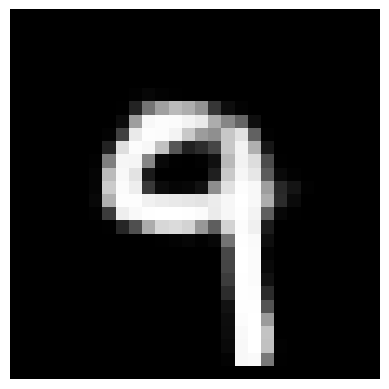

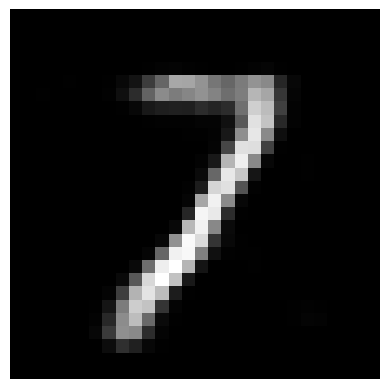

(None, None)

In [70]:
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

# Latent Space Grid Visualization

In [75]:
def plot_latent_space(model, scale, digit_size=28, figsize=15):

    """
    Plots the latent space by generating a grid of images using t-SNE.

    Args:
        model: The trained VAE model.
        scale: Scaling factor for the latent space.
        digit_size: The size of the generated digits (default 28x28).
        figsize: Figure size for the plot.
    """
    model.eval()  # Set model to evaluation mode

    grid_size = 15  # Define the number of points per row/column
    z_dim = model.encoder.fc2.out_features // 2  # Get latent dimension (200)

    # Generate 5000 random latent samples from normal distribution
    latent_samples = np.random.randn(5000, z_dim)

    # Reduce the latent space from 200D to 2D using t-SNE
    print("Applying t-SNE to reduce latent space...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    latent_2d = tsne.fit_transform(latent_samples)

    # Create a 2D grid based on t-SNE output range
    grid_x = np.linspace(latent_2d[:, 0].min() * scale, latent_2d[:, 0].max() * scale, grid_size)
    grid_y = np.linspace(latent_2d[:, 1].min() * scale, latent_2d[:, 1].max() * scale, grid_size)

    # Create an empty canvas for images
    figure = np.zeros((digit_size * grid_size, digit_size * grid_size))

    # Generate images by decoding latent space grid points
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            # Find the closest real t-SNE point to interpolate
            closest_idx = np.argmin(np.sum((latent_2d - np.array([xi, yi])) ** 2, axis=1))
            z_sampled = torch.tensor(latent_samples[closest_idx], dtype=torch.float32).to(device).unsqueeze(0)

            with torch.no_grad():
                generated_image = model.decoder(z_sampled).squeeze().cpu().numpy()
                generated_image = generated_image.reshape(digit_size, digit_size)

            # Assign the generated image to the grid
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = generated_image

    # Plot the final latent space visualization
    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="gray")
    plt.axis("off")
    plt.title("VAE Latent Space Grid using t-SNE")
    plt.show()

Applying t-SNE to reduce latent space...


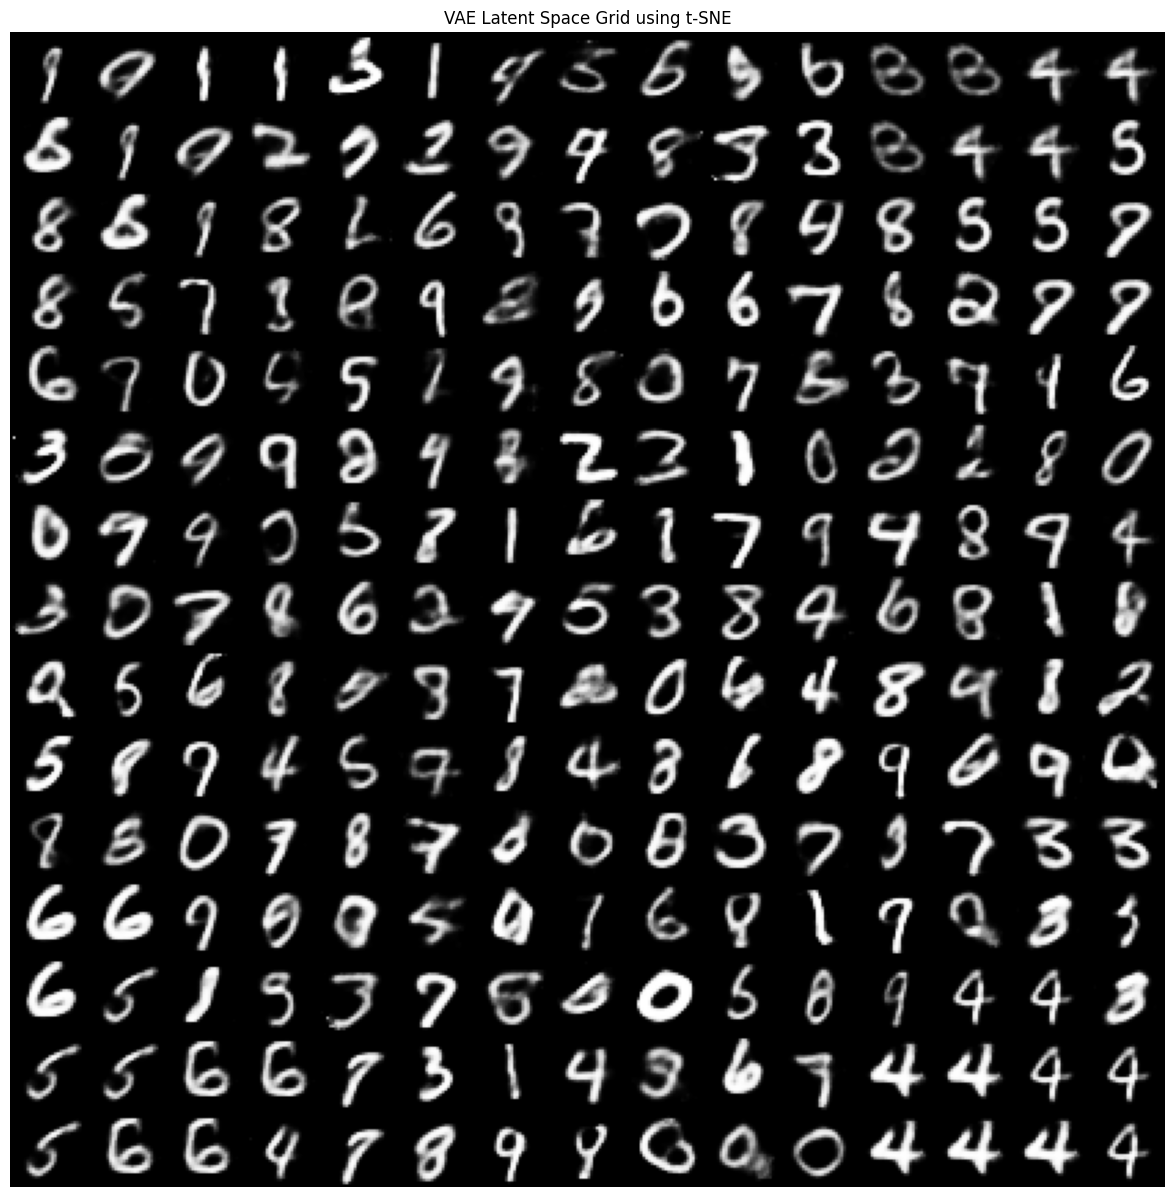

In [76]:
plot_latent_space(model, scale=1.0)

Applying t-SNE to reduce latent space...


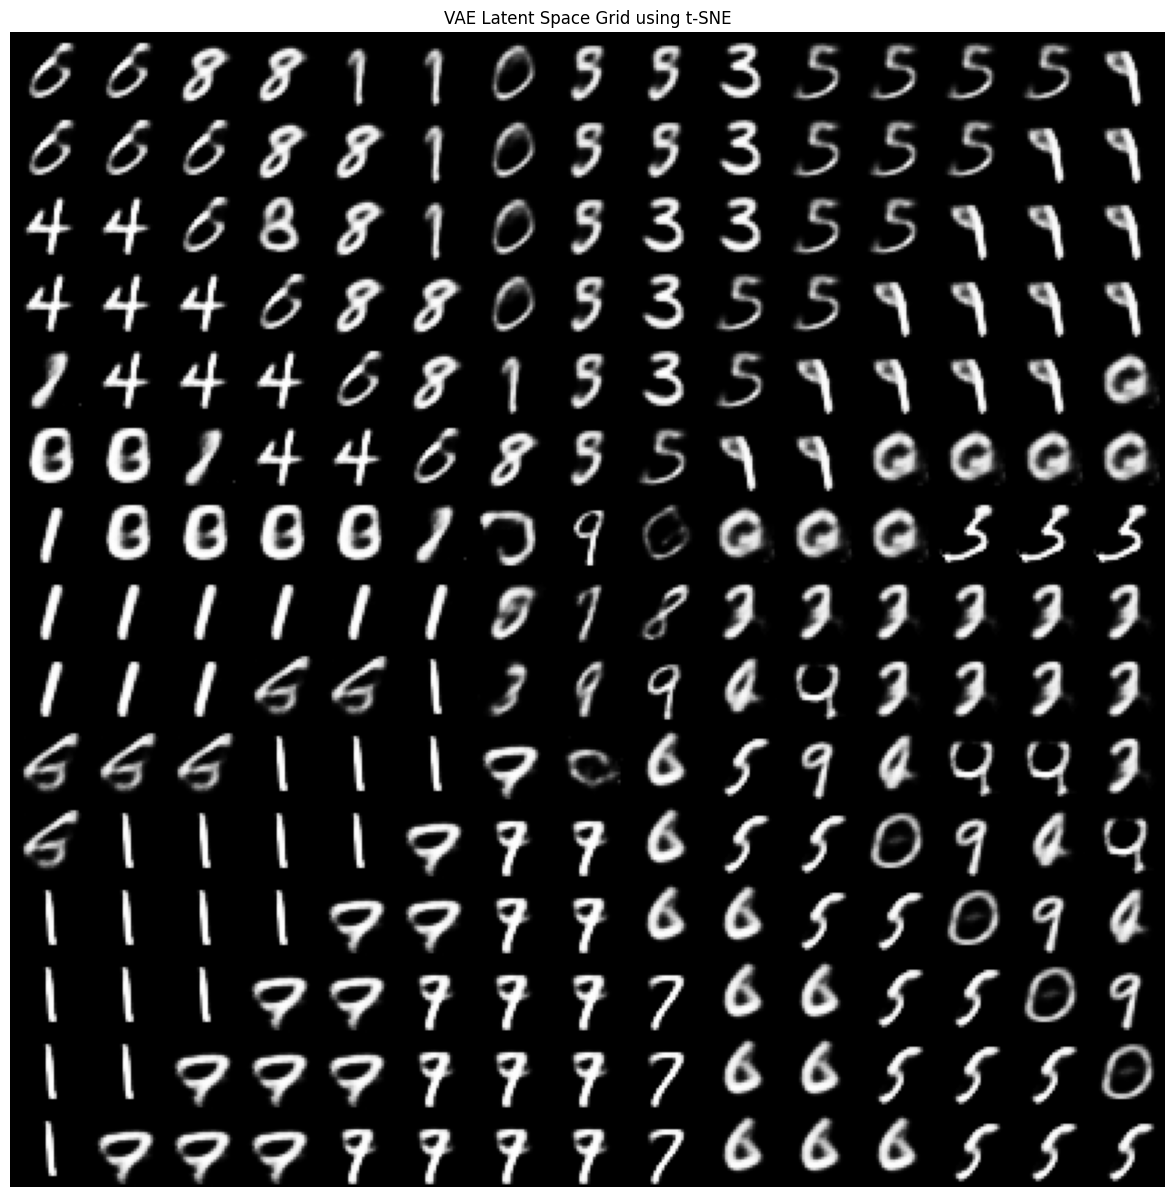

In [77]:
plot_latent_space(model, scale=5.0)

# Linear Interpolation

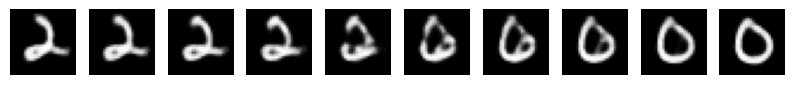

In [80]:
# write your code here
def linear_interpolation(model,dataset,num_steps=10):

  model.eval()

  # select two random digits
  indx1,indx2=random.sample(range(len(dataset)),2)

  img1,label1=dataset[indx1]
  img2,label2=dataset[indx2]



  img1=img1.view(1,-1).to(device)
  img2=img2.view(1,-1).to(device)


  with torch.no_grad():

    mu1,logvar1=model.encoder(img1)
    mu2,logvar2=model.encoder(img2)


    z1=mu1
    z2=mu2


  t_values=torch.linspace(0,1,num_steps,device=device)

  fig,axes=plt.subplots(1,num_steps,figsize=(num_steps,2))


  for i,t in enumerate(t_values):

    z_interpolated=(1-t)*z1 + t*z2

    with torch.no_grad():

      x_decoded=model.decoder(z_interpolated)

    digit_img=x_decoded.squeeze().cpu().detach().numpy()
    digit_img=digit_img.reshape(28,28)

    axes[i].imshow(digit_img,cmap='gray')
    axes[i].axis('off')


  plt.show()





linear_interpolation(model,test_dataset,num_steps=10)

